# ESS8 Belief Data — Exploration

Processed from ESS Round 8 (2016) following Broere et al. (2022).  
20 belief dimensions, coded higher = right-wing/conservative, normalised to [0, 1].

## Imports

In [1]:
import sys
sys.path.insert(0, "../src")

import os
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from belief_network import BeliefNetwork

sns.set_theme(style="whitegrid")
%matplotlib inline

## Load data

In [2]:
DATA_PATH = "../input/data/ESS8e02_3_self_processed/ess8_cca_initial_beliefs.csv"

df = pd.read_csv(DATA_PATH)

BELIEF_DIMS = [
    "left_right_identification", "gender_inequality", "anti_lgbt",
    "euroscepticism", "anti_immigration", "anti_egalitarianism",
    "benefits_harm_economy", "benefits_harm_society", "welfare_chauvinism",
    "anti_economic_interventionism", "anti_social_benefits_low_income",
    "anti_social_benefits_parents", "educational_spending",
    "anti_basic_income", "anti_climate_change_taxes",
    "anti_climate_change_renewables", "anti_climate_ban_appliances",
    "climate_skepticism", "authoritarianism", "anti_libertarianism",
]

print(f"Respondents: {len(df):,}")
print(f"Countries:   {sorted(df['cntry'].unique())}")
print(f"Belief dims: {len(BELIEF_DIMS)}")
df.head()

Respondents: 37,118
Countries:   ['AT', 'BE', 'CH', 'CZ', 'DE', 'EE', 'ES', 'FI', 'FR', 'GB', 'HU', 'IE', 'IL', 'IS', 'IT', 'LT', 'NL', 'NO', 'PL', 'PT', 'RU', 'SE', 'SI']
Belief dims: 20


,ess_row_id,idno,cntry,country_name,ess_unique_id,agea,gndr,eisced,education_3cat,hinctnta,...,educational_spending,anti_basic_income,anti_climate_change_taxes,anti_climate_change_renewables,anti_climate_ban_appliances,climate_skepticism,authoritarianism,anti_libertarianism,n_belief_missing,n_belief_available
0,1,1,AT,Austria,AT_1,34.0,2.0,7.0,3.0,NaN,...,NaN,0.000000,0.00,0.00,0.25,0.25,0.20,0.28,1,19
1,2,2,AT,Austria,AT_2,52.0,1.0,4.0,2.0,5.0,...,0.666667,0.333333,0.00,0.25,0.25,0.25,0.24,0.44,0,20
2,3,4,AT,Austria,AT_4,68.0,2.0,3.0,2.0,2.0,...,0.333333,1.000000,0.75,0.25,0.25,0.25,0.72,0.56,0,20
3,4,6,AT,Austria,AT_6,54.0,1.0,3.0,2.0,4.0,...,0.666667,NaN,0.50,0.50,0.50,0.50,0.68,0.28,2,18
4,5,10,AT,Austria,AT_10,20.0,2.0,3.0,2.0,2.0,...,0.333333,0.333333,0.50,0.00,0.75,0.25,0.48,0.40,0,20


In [ ]:
df

## Belief network inference

We infer a weighted undirected network over the 20 belief dimensions using the MDL method of Peixoto (2025).

**Generative model**: multivariate Gaussian — respondents are i.i.d. samples from a Normal distribution whose precision matrix (inverse covariance) encodes the network edge weights. Edges that can be explained away by indirect paths are pruned by the MDL prior.

**Implementation**: `PseudoNormalBlockState` from graph-tool. This uses a pseudolikelihood approximation (belief propagation) together with a nested stochastic block model as the structural prior, which provides the MDL regularisation without requiring cross-validation.

**Data layout**: graph-tool expects an `(N, M)` array — rows are the N=20 nodes (belief dimensions), columns are the M respondents (independent samples).

**Missing values**: the state requires complete data. We use per-column mean imputation, which is conservative (pulls partial observations toward the centre) but retains all respondents.

In [7]:
bn = BeliefNetwork(BELIEF_DIMS)
bn.fit(df[df.cntry == "GB"])

iter  100 | DL = -5872.9 | edges = 101
Converged at iteration 181

Final description length : -5982.8
Inferred edges           : 95


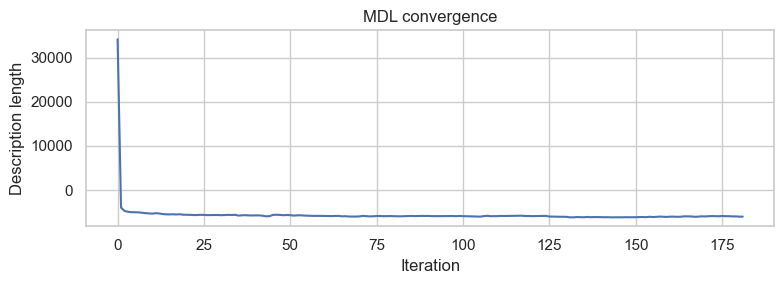

In [8]:
bn.plot_convergence()
plt.tight_layout()
plt.show()

In [9]:
bn.get_edge_list()

,source,target,weight
0,left_right_identification,authoritarianism,-2.756743
1,left_right_identification,euroscepticism,-2.756743
2,left_right_identification,benefits_harm_economy,-4.367009
3,left_right_identification,educational_spending,-1.446244
4,left_right_identification,anti_basic_income,-1.424078
...,...,...,...
90,anti_libertarianism,anti_immigration,-2.093280
91,anti_libertarianism,educational_spending,1.285850
92,anti_libertarianism,anti_lgbt,-4.228463
93,anti_libertarianism,climate_skepticism,-1.424078


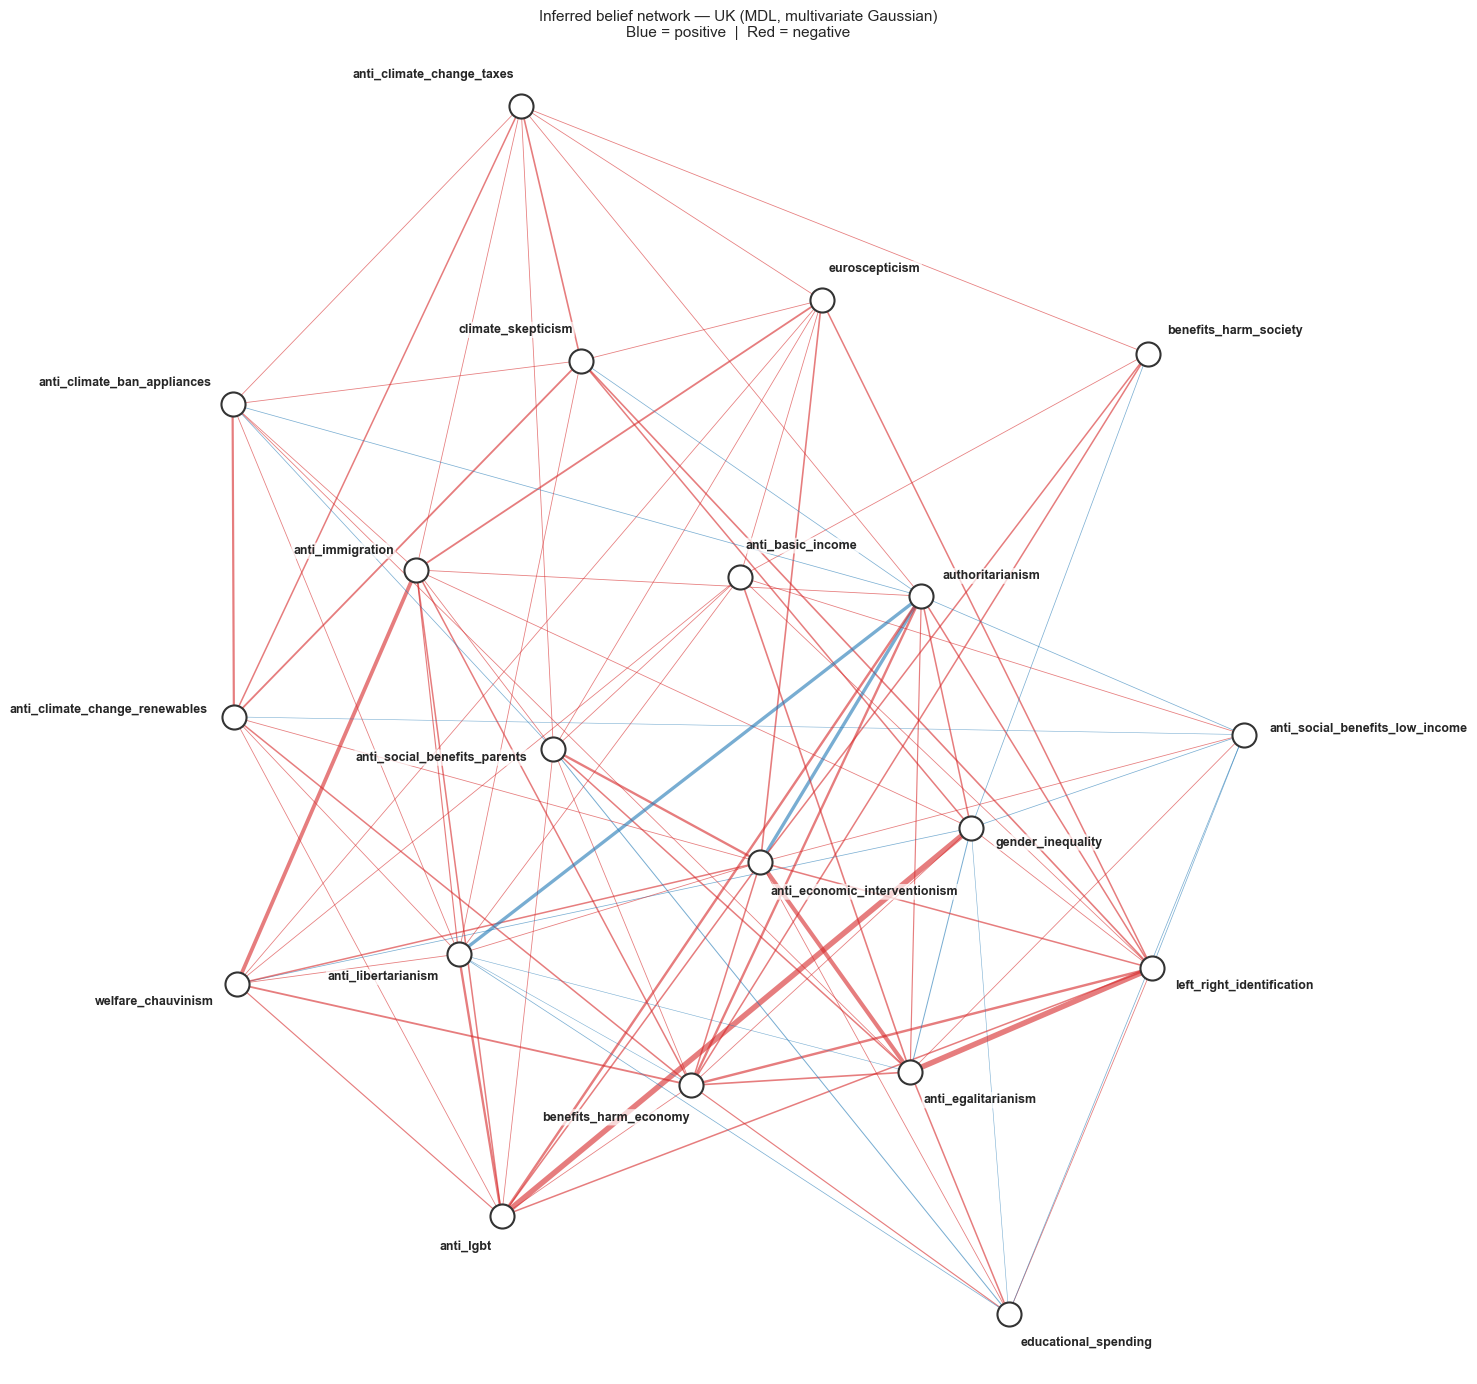

In [10]:
bn.plot_network(title="Inferred belief network — UK (MDL, multivariate Gaussian)\n"
                "Blue = positive  |  Red = negative")
plt.tight_layout()
plt.show()

In [11]:
bn.save('../output/networks/UK.graphml')